In [ ]:
import numpy as np
import pandas as pd
from sklearn.calibration import LabelEncoder
from sklearn.discriminant_analysis import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import xgboost as xgb
from imblearn.over_sampling import SMOTE

# Load the dataset
data = pd.read_csv('PaySim\\PS_20174392719_1491204439457_log.csv')  # Replace with actual file path

# Label Encoding for high-cardinality 'nameOrig' and 'nameDest'
le_nameOrig = LabelEncoder()
le_nameDest = LabelEncoder()
le_type = LabelEncoder()
data['nameOrig_encoded'] = le_nameOrig.fit_transform(data['nameOrig'])
data['nameDest_encoded'] = le_nameDest.fit_transform(data['nameDest'])
data['type_encoded'] = le_nameDest.fit_transform(data['type'])

# Drop the original columns to save memory
data.drop(columns=['nameOrig', 'nameDest', 'type'], inplace=True)
data.drop(columns=['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest'], inplace=True)

# List of numerical features to scale
numerical_features = ['step', 'amount']

plot = data.copy()
# Scale numerical features to ensure standardized values
scaler = StandardScaler()
data[numerical_features] = scaler.fit_transform(data[numerical_features])

# Check the mean (~0) and standard deviation (~1) of the scaled features
scaled_stats = data[numerical_features].agg(['mean', 'std'])
print(scaled_stats)
print()

# Step 4: Data balancing using SMOTE for the target variable 'isFraud'
X = data.drop(columns=['isFraud'])  # Features
y = data['isFraud']                # Target 

smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

print("Original shape:", X.shape, y.shape)
print("Original class distribution:", np.bincount(y))
print("Balanced shape:", X_balanced.shape, y_balanced.shape)
print("Balanced class distribution:", np.bincount(y_balanced))
print()

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shape of each split
print("Training set (features):", X_train.shape)
print("Training set (target):", y_train.shape)
print("Test set (features):", X_test.shape)
print("Test set (target):", y_test.shape)
print()

# Check the distribution of the target (fraud vs. non-fraud)
print("Training set fraud distribution:")
print(y_train.value_counts())
print()

print("Test set fraud distribution:")
print(y_test.value_counts())


              step        amount
mean -1.909724e-16 -4.946736e-17
std   1.000000e+00  1.000000e+00

Original shape: (6362620, 6) (6362620,)
Original class distribution: [6354407    8213]
Balanced shape: (12708814, 6) (12708814,)
Balanced class distribution: [6354407 6354407]

Training set (features): (5090096, 6)
Training set (target): (5090096,)
Test set (features): (1272524, 6)
Test set (target): (1272524,)

Training set fraud distribution:
isFraud
0    5083503
1       6593
Name: count, dtype: int64

Test set fraud distribution:
isFraud
0    1270904
1       1620
Name: count, dtype: int64


In [173]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'isFraud' is the target variable
corr_matrix = data.corr()

# Focus on correlation with the fraud column
# fraud_corr = corr_matrix['isFraud'].sort_values(ascending=False)

# Plot the correlations
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()


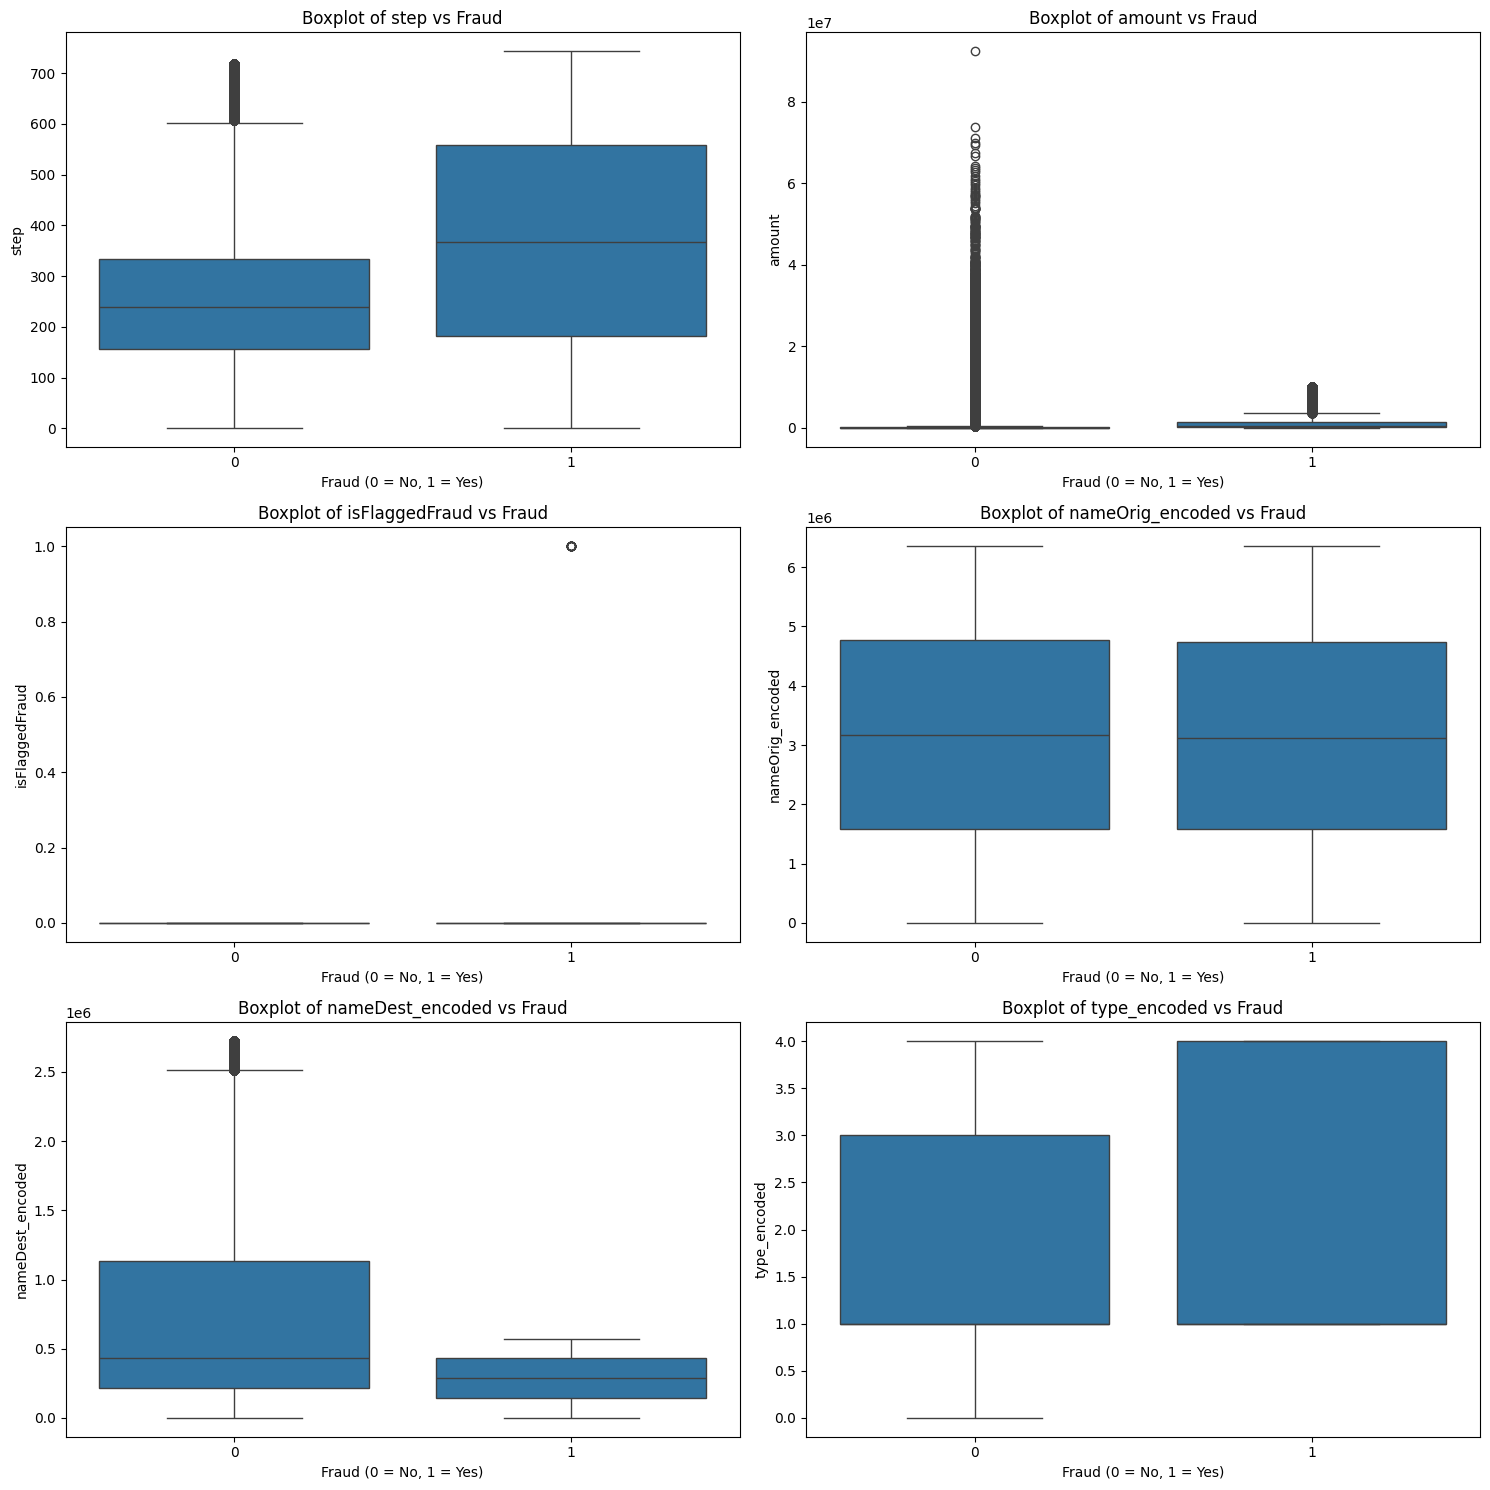

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
# Extract all features except 'isFraud'
features = [col for col in plot.columns if col != 'isFraud']

# Set up a large figure for multiple subplots
num_features = len(features)
fig, axes = plt.subplots(nrows=(num_features // 2 + num_features % 2), ncols=2, figsize=(15, 5 * (num_features // 2 + num_features % 2)))
axes = axes.flatten()

# Generate boxplots for each feature in the dataset
for i, feature in enumerate(features):
    sns.boxplot(x='isFraud', y=feature, data=plot, ax=axes[i])
    axes[i].set_title(f'Boxplot of {feature} vs Fraud')
    axes[i].set_xlabel('Fraud (0 = No, 1 = Yes)')
    axes[i].set_ylabel(feature)

# Remove any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Extract all features except 'isFraud'
features = [col for col in data.columns if col != 'isFraud']

# Set up a large figure for multiple subplots
num_features = len(features)
fig, axes = plt.subplots(nrows=(num_features // 2 + num_features % 2), ncols=2, figsize=(15, 5 * (num_features // 2 + num_features % 2)))
axes = axes.flatten()

# Generate density plots for each feature in the dataset
for i, feature in enumerate(features):
    sns.histplot(data=data, x=feature, hue='isFraud', element='step', stat='density', common_norm=False, ax=axes[i], kde=True)
    axes[i].set_title(f'Distribution of {feature} by Fraud')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Density')

# Remove any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [176]:

import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Initialize Isolation Forest
isolation_forest = IsolationForest(n_estimators=500, contamination=0.1, random_state=42) # 0.3 contamination higher -> recall higher

# Fit the model on training data
isolation_forest.fit(X_train)

# data = data.loc[data.index].copy()
anomalie_scores = isolation_forest.decision_function(X_test)
anomalies = isolation_forest.predict(X_test)

print((anomalies == 1).sum())
print((anomalies == -1).sum())
print((y_test == 0).sum())
print((y_test == 1).sum())


1145319
127205
1270904
1620


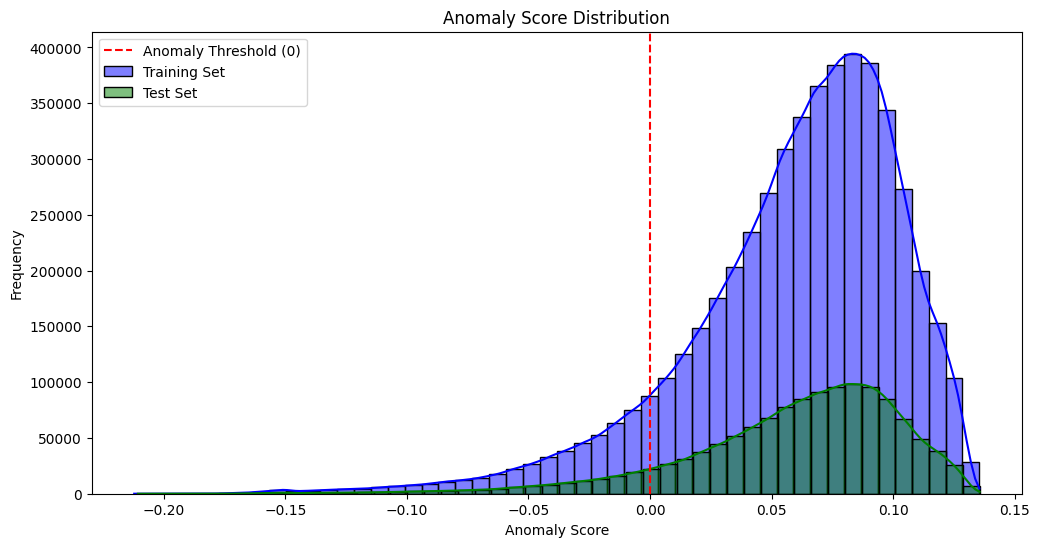

In [177]:
train_anomaly_scores = isolation_forest.decision_function(X_train)
test_anomaly_scores = isolation_forest.decision_function(X_test)

plt.figure(figsize=(12, 6))
sns.histplot(train_anomaly_scores, bins=50, color='blue', kde=True, label='Training Set')
sns.histplot(test_anomaly_scores, bins=50, color='green', kde=True, label='Test Set')
plt.axvline(x=0, color='red', linestyle='--', label='Anomaly Threshold (0)')
plt.title('Anomaly Score Distribution')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')
plt.legend()
plt.show()


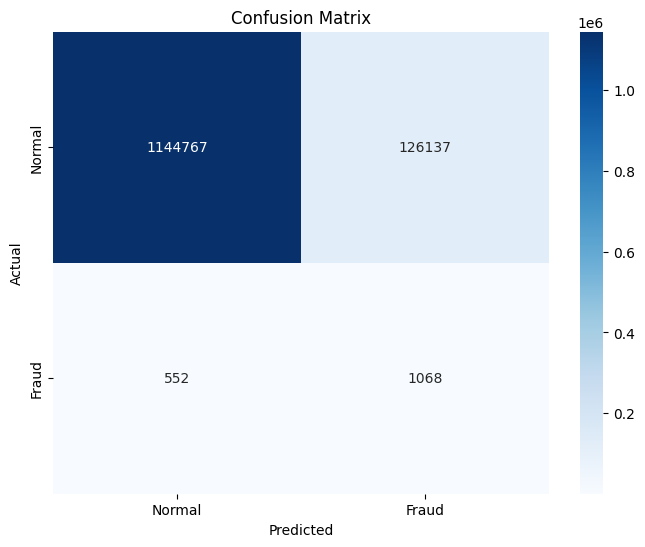


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95   1270904
           1       0.01      0.66      0.02      1620

    accuracy                           0.90   1272524
   macro avg       0.50      0.78      0.48   1272524
weighted avg       1.00      0.90      0.95   1272524



In [178]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Generate predictions based on anomaly scores
threshold = 0  # Define your threshold
y_pred = (isolation_forest.decision_function(X_test) < threshold).astype(int)  # 1 for anomaly, 0 for normal

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)  # y_test is the true labels
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


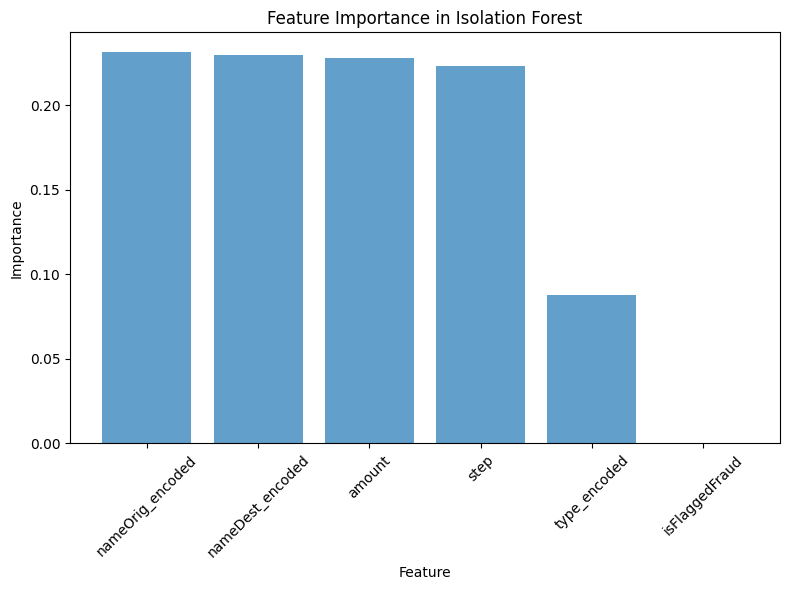

In [179]:
import numpy as np


# Extract feature importance
tree_feature_importances = []
for estimator in isolation_forest.estimators_:
    tree_feature_importances.append(estimator.feature_importances_)

# Average importance across all trees
feature_importances = np.mean(tree_feature_importances, axis=0)

# Combine names and importances into a DataFrame
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)

# Visualization
plt.figure(figsize=(8, 6))
plt.bar(importance_df["Feature"], importance_df["Importance"], alpha=0.7)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance in Isolation Forest")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


The scores you see in the scatter plot above have been adjusted. To do this, the package first calculates an offset. This is the anomaly score percentile based on the contamination value. In our case, the offset will be the 0.99 percentile. The final scores are then given by offset - score. Doing this means that all scores below 0 suggest potential anomalies.

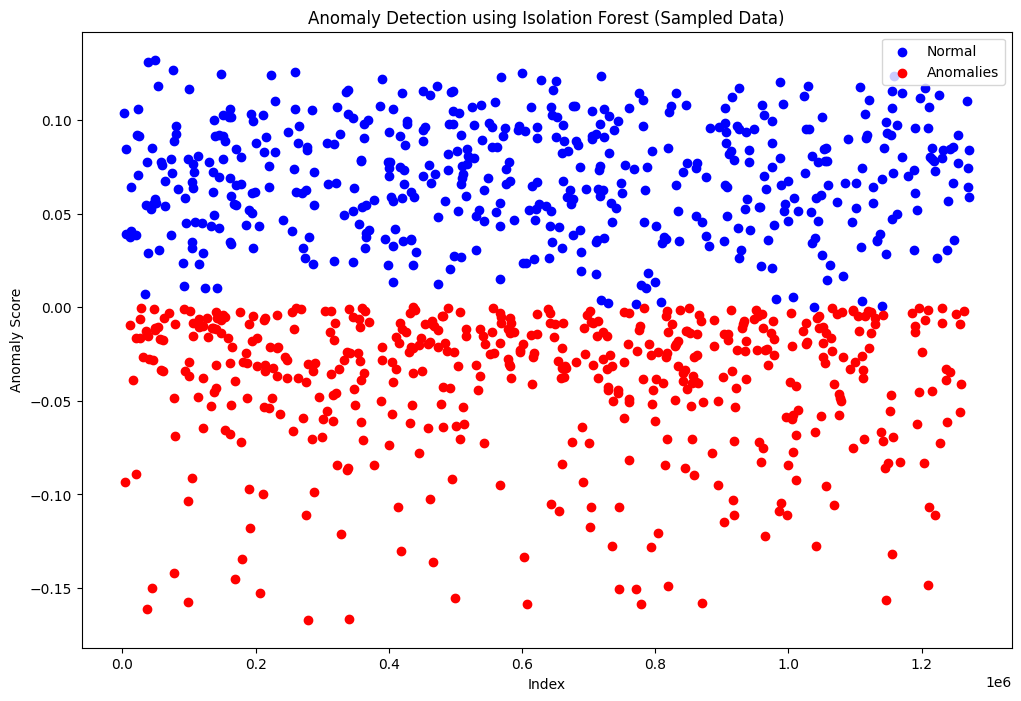

In [180]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming anomalie_scores and anomalies are NumPy arrays or Pandas Series
anomalie_scores = pd.Series(anomalie_scores)  # Ensure anomaly scores are in a Pandas Series
anomalies = pd.Series(anomalies)  # Ensure anomalies (-1 for anomalies, 1 for normal) are in a Pandas Series

# Filter normal and anomalous instances
normal_indices = anomalies[anomalies == 1].index
anomalous_indices = anomalies[anomalies == -1].index

# Sample size (adjust as needed)
sample_size = 500  # Number of points to sample

# Take a sample of normal instances
normal_sample_indices = normal_indices.to_series().sample(n=min(sample_size, len(normal_indices)), random_state=42).index
normal_sample_scores = anomalie_scores.loc[normal_sample_indices]

# Take a sample of anomalous instances
anomalous_sample_indices = anomalous_indices.to_series().sample(n=min(sample_size, len(anomalous_indices)), random_state=42).index
anomalous_sample_scores = anomalie_scores.loc[anomalous_sample_indices]

# Create a larger figure
plt.figure(figsize=(12, 8))

# Plot normal instances
plt.scatter(normal_sample_indices, normal_sample_scores, label='Normal', color='blue')

# Plot anomalies
plt.scatter(anomalous_sample_indices, anomalous_sample_scores, label='Anomalies', color='red')

# Add labels and legend
plt.xlabel('Index')
plt.ylabel('Anomaly Score')
plt.legend()
plt.title('Anomaly Detection using Isolation Forest (Sampled Data)')
plt.show()


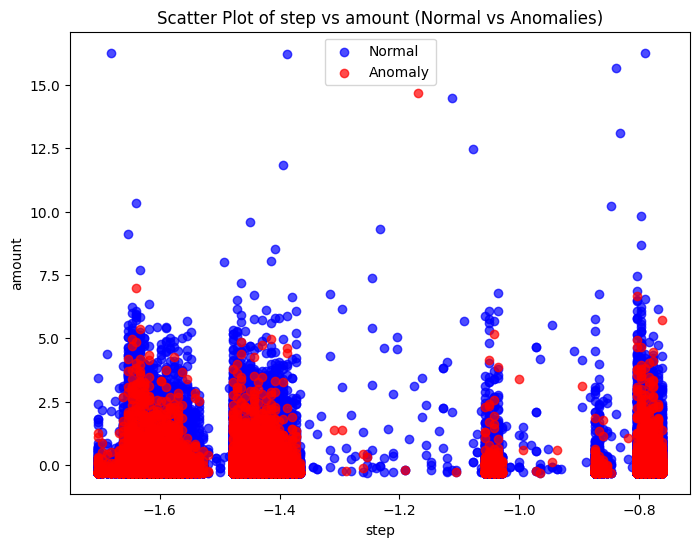

In [181]:

# Use .where to filter normal and anomalous rows
normal = X_test.where(anomalies == 1).dropna()  # Keep rows where anomalies == 1
anomalous = X_test.where(anomalies == -1).dropna()  # Keep rows where anomalies == -1

# Select two features for plotting (replace with your desired feature names)
feature_x = 'step'  
feature_y = 'amount'    

# Create the scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(normal[feature_x], normal[feature_y], label='Normal', alpha=0.7, c='blue')
plt.scatter(anomalous[feature_x], anomalous[feature_y], label='Anomaly', alpha=0.7, c='red')

# Add labels, legend, and title
plt.xlabel(feature_x)
plt.ylabel(feature_y)
plt.legend()
plt.title(f"Scatter Plot of {feature_x} vs {feature_y} (Normal vs Anomalies)")
plt.show()

Visualize the tree

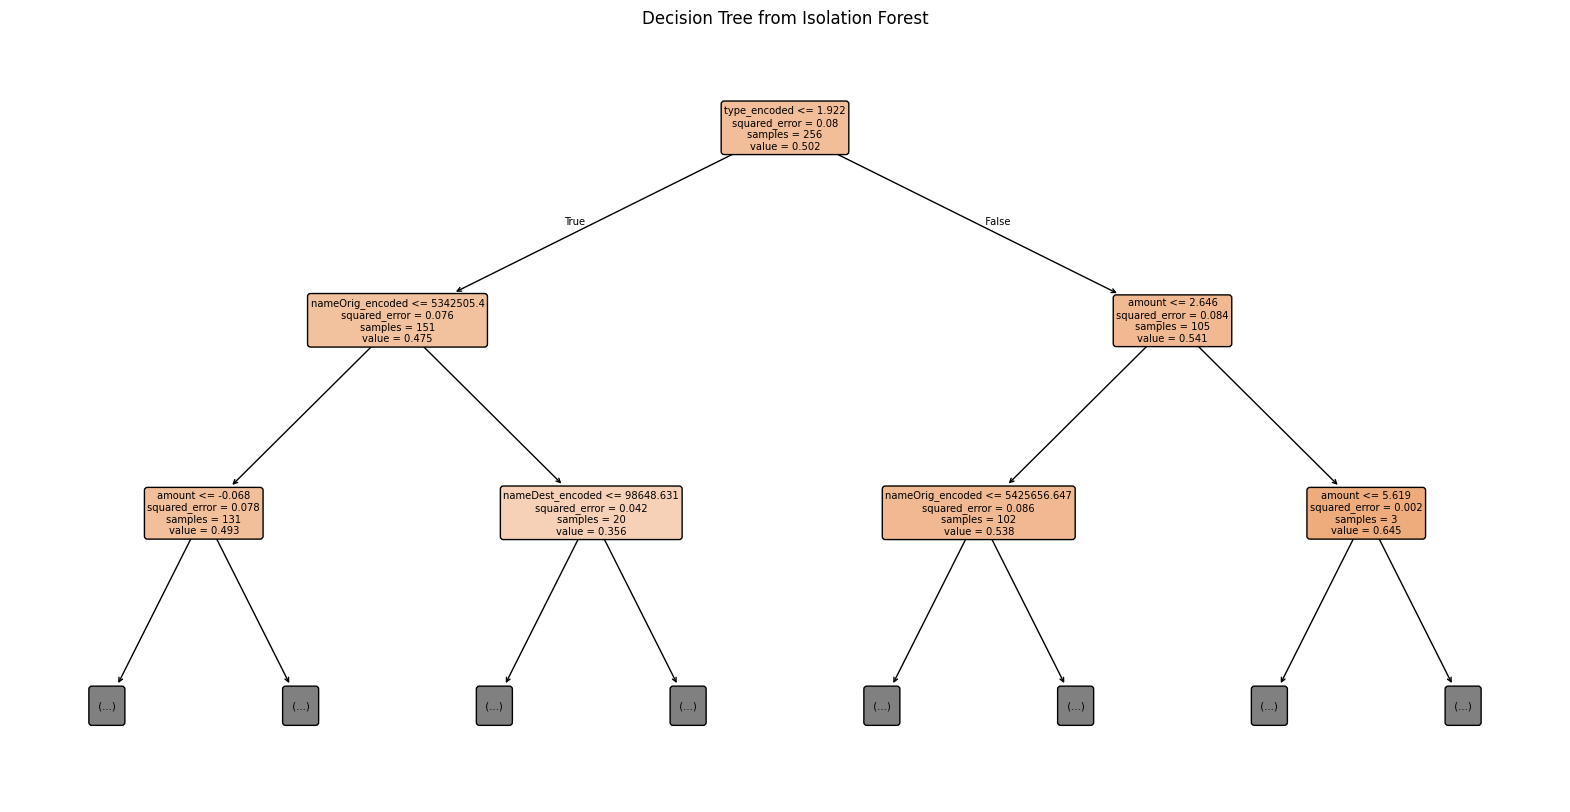

In [182]:
from sklearn.tree import plot_tree
single_tree = isolation_forest.estimators_[0]  # Get the first tree in the forest
plt.figure(figsize=(20, 10))
plot_tree(single_tree, 
          feature_names=X_train.columns, 
          filled=True, 
          rounded=True,
          max_depth=2)  # Restrict visualization to the top 2 levels
plt.title("Decision Tree from Isolation Forest")
plt.show()


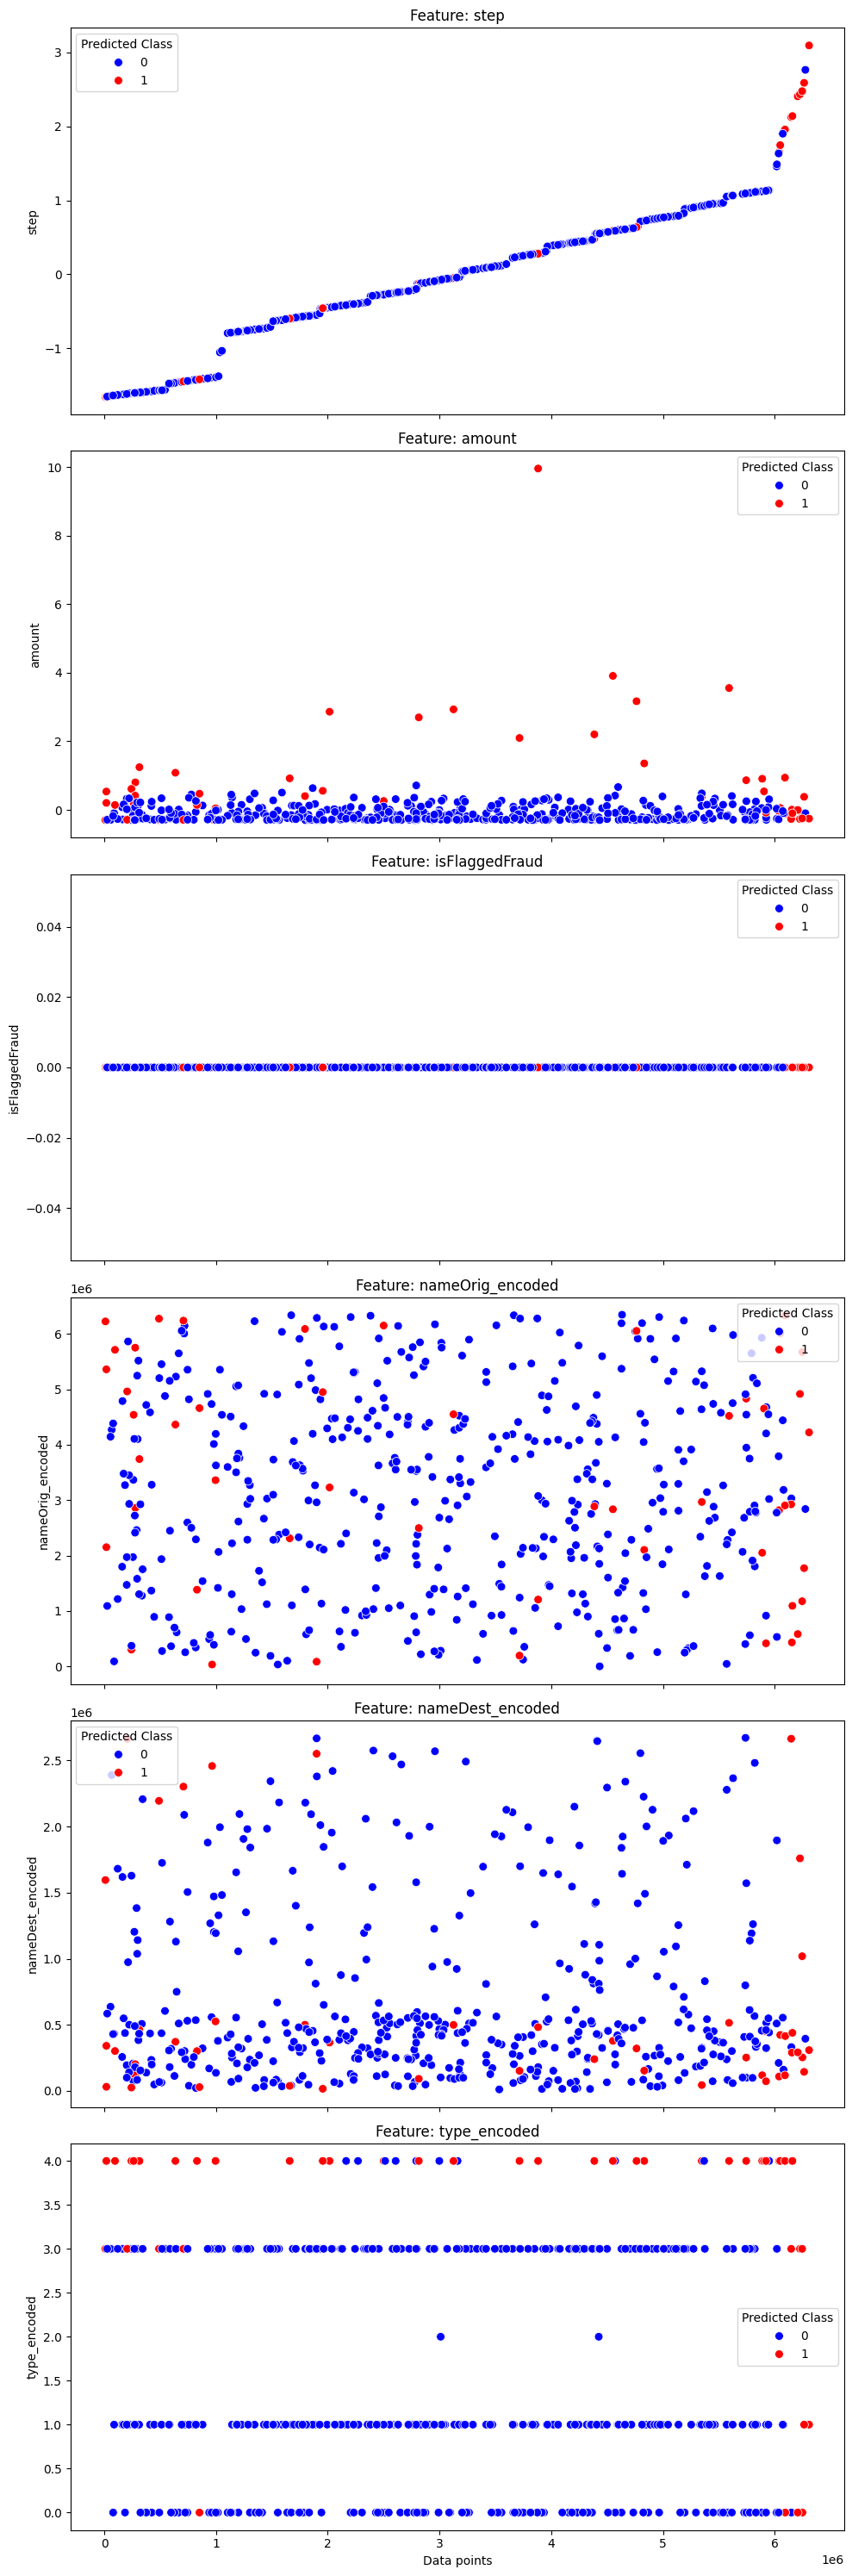

In [183]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming X_test and y_pred are available
# X_test = [Your Test Dataset]
# y_pred = [Your Predicted Labels]

# Create a copy of X_test and add predicted labels
visualization_data = X_test.copy()
visualization_data['predicted_class'] = y_pred

# Take a random sample of 500 rows
sampled_data = visualization_data.sample(n=500, random_state=42)

# Create a figure and axes for subplots
num_features = len(X_test.columns)
fig, axes = plt.subplots(nrows=num_features, figsize=(10, 5 * num_features), sharex=True)

# Plot each feature in a single subplot
for ax, col in zip(axes, X_test.columns):
    sns.scatterplot(
        x=sampled_data.index,
        y=sampled_data[col],
        hue=sampled_data['predicted_class'],
        palette={0: 'blue', 1: 'red'},
        s=50,
        ax=ax
    )
    ax.set_title(f'Feature: {col}')
    ax.set_ylabel(col)
    ax.legend(title='Predicted Class', loc='best')

plt.xlabel('Data points')
plt.tight_layout()
plt.show()

